In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = {
    "Customer": ["Aman","Rahul","Priya","Neha","Rohit"],
    "Gender": ["Male","Male","Female","Female","Male"],
    "City": ["Delhi","Mumbai","Delhi","Lucknow","Mumbai"],
    "Age": [22,35,28,41,30],
    "Salary": [25000,50000,42000,65000,38000],
    "Purchase": [1500,2200,1800,3500,2700],
    "Joining_Date": [
        "2022-01-10",
        "2021-06-15",
        "2023-03-20",
        "2020-11-01",
        "2022-09-05"
    ]
}

df = pd.DataFrame(data)
df

,Customer,Gender,City,Age,Salary,Purchase,Joining_Date
0,Aman,Male,Delhi,22,25000,1500,2022-01-10
1,Rahul,Male,Mumbai,35,50000,2200,2021-06-15
2,Priya,Female,Delhi,28,42000,1800,2023-03-20
3,Neha,Female,Lucknow,41,65000,3500,2020-11-01
4,Rohit,Male,Mumbai,30,38000,2700,2022-09-05


In [9]:
print("--- Dataset Inspection ---")
print("Shape : ",df.shape)
print("\nColumns : ")
print( df.columns)
print("\nInfo :")
print(df.info())
print("\n Describe :")
print(df.describe())

--- Dataset Inspection ---
Shape :  (5, 7)

Columns : 
Index(['Customer', 'Gender', 'City', 'Age', 'Salary', 'Purchase',
       'Joining_Date'],
      dtype='str')

Info :
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Customer      5 non-null      str  
 1   Gender        5 non-null      str  
 2   City          5 non-null      str  
 3   Age           5 non-null      int64
 4   Salary        5 non-null      int64
 5   Purchase      5 non-null      int64
 6   Joining_Date  5 non-null      str  
dtypes: int64(3), str(4)
memory usage: 538.0 bytes
None

 Describe :
             Age       Salary    Purchase
count   5.000000      5.00000     5.00000
mean   31.200000  44000.00000  2340.00000
std     7.190271  14815.53239   789.30349
min    22.000000  25000.00000  1500.00000
25%    28.000000  38000.00000  1800.00000
50%    30.000000  42000.00000  2200.00000
75%    

In [15]:
print("\n Creating New Features")
print("\n Purchase Ratio")
df['Purchase_Ratio']=df['Purchase']/df['Salary']
print(df[["Purchase","Salary","Purchase_Ratio"]])

print("\n Salary Per Age")
df['Salary_per_Age']=df['Salary']/df['Age']
print(df[["Salary","Age","Salary_per_Age"]])

print("\n Experience Years")
df["Joining_Date"]= pd.to_datetime(df["Joining_Date"])
today = pd.Timestamp.today()
df["Experience_Years"] = ((today- df["Joining_Date"]).dt.days / 365.25).round(1)
print(df[["Customer","Joining_Date","Experience_Years"]])


 Creating New Features

 Purchase Ratio
   Purchase  Salary  Purchase_Ratio
0      1500   25000        0.060000
1      2200   50000        0.044000
2      1800   42000        0.042857
3      3500   65000        0.053846
4      2700   38000        0.071053

 Salary Per Age
   Salary  Age  Salary_per_Age
0   25000   22     1136.363636
1   50000   35     1428.571429
2   42000   28     1500.000000
3   65000   41     1585.365854
4   38000   30     1266.666667

 Experience Years
  Customer Joining_Date  Experience_Years
0     Aman   2022-01-10               4.5
1    Rahul   2021-06-15               5.1
2    Priya   2023-03-20               3.3
3     Neha   2020-11-01               5.7
4    Rohit   2022-09-05               3.8


In [22]:
print("Label Encoding :\n")
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender_Encoded"]  = le.fit_transform(df["Gender"])

print(df[["Gender","Gender_Encoded"]])

Label Encoding :

   Gender  Gender_Encoded
0    Male               1
1    Male               1
2  Female               0
3  Female               0
4    Male               1


In [23]:
print("One Hot Encoding : \n")
city_encoded = pd.get_dummies(df["City"],prefix="City",dtype=int)
df = pd.concat([df,city_encoded],axis=1)
print(df)

One Hot Encoding : 

  Customer  Gender     City  Age  Salary  Purchase Joining_Date  \
0     Aman    Male    Delhi   22   25000      1500   2022-01-10   
1    Rahul    Male   Mumbai   35   50000      2200   2021-06-15   
2    Priya  Female    Delhi   28   42000      1800   2023-03-20   
3     Neha  Female  Lucknow   41   65000      3500   2020-11-01   
4    Rohit    Male   Mumbai   30   38000      2700   2022-09-05   

   Purchase_Ratio  Salary_per_Age  Experience_Years  Gender_Encoded  \
0        0.060000     1136.363636               4.5               1   
1        0.044000     1428.571429               5.1               1   
2        0.042857     1500.000000               3.3               0   
3        0.053846     1585.365854               5.7               0   
4        0.071053     1266.666667               3.8               1   

   City_Delhi  City_Lucknow  City_Mumbai  City_Delhi  City_Lucknow  \
0           1             0            0           1             0   
1        

In [24]:
df["Joining_Date"] = pd.to_datetime(df["Joining_Date"])

df["Joining_Year"] = df["Joining_Date"].dt.year
df["Joining_Month"] = df["Joining_Date"].dt.month
df["Joining_Day"] = df["Joining_Date"].dt.day

print(df[["Joining_Date",
          "Joining_Year",
          "Joining_Month",
          "Joining_Day"]])

  Joining_Date  Joining_Year  Joining_Month  Joining_Day
0   2022-01-10          2022              1           10
1   2021-06-15          2021              6           15
2   2023-03-20          2023              3           20
3   2020-11-01          2020             11            1
4   2022-09-05          2022              9            5


In [25]:
bins = [0, 25, 40, 100]
labels = ["Young", "Adult", "Senior"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df[["Age", "Age_Group"]])

   Age Age_Group
0   22     Young
1   35     Adult
2   28     Adult
3   41    Senior
4   30     Adult


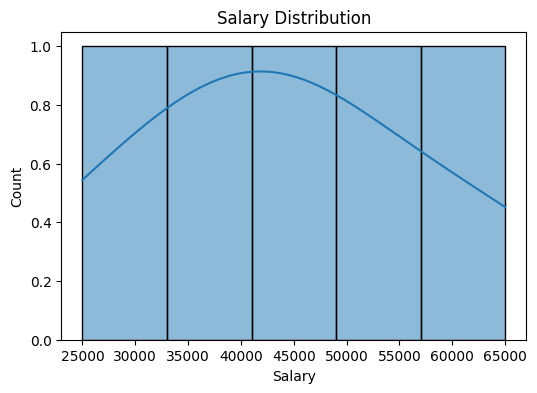

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["Salary"], bins=5, kde=True)

plt.title("Salary Distribution")
plt.show()

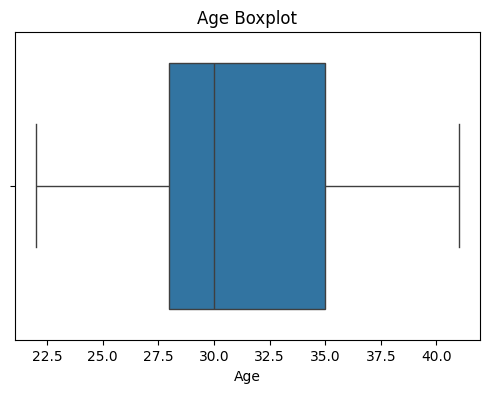

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"])

plt.title("Age Boxplot")
plt.show()

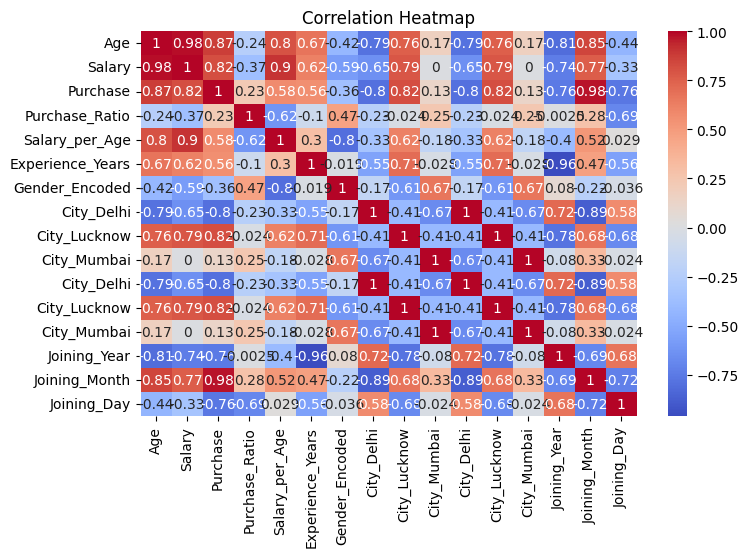

In [28]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()